# Air Quality Hotspot Identification in Bangalore

In [1]:
import folium
from folium.plugins import MarkerCluster
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

# Configure plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


## 2. Station Coordinates

In [2]:
# Station coordinates for geographic mapping
STATION_COORDINATES = {
    'BTM Layout': {'lat': 12.9165, 'lon': 77.6101},
    'Bapuji Nagar': {'lat': 12.9634, 'lon': 77.5354},
    'City Railway Station': {'lat': 12.9781, 'lon': 77.5696},
    'Hebbal': {'lat': 13.0354, 'lon': 77.5988},
    'Hombegowda Nagar': {'lat': 12.9389, 'lon': 77.5962},
    'Jayanagar 5th Block': {'lat': 12.9238, 'lon': 77.5851},
    'Jigani': {'lat': 12.7840, 'lon': 77.6409},
    'Kasturi Nagar': {'lat': 13.0165, 'lon': 77.6622},
    'Peenya': {'lat': 13.0285, 'lon': 77.5197},
    'RVCE-Mailasandra': {'lat': 12.9242, 'lon': 77.4984},
    'Sanegurava Halli': {'lat': 12.9897, 'lon': 77.5457},
    'Shivapura Peenya': {'lat': 13.0315, 'lon': 77.5167},
    'Silk Board': {'lat': 12.9175, 'lon': 77.6234},
    'BWSSB Kadabesanahalli': {'lat': 12.9378, 'lon': 77.6946}
}

print(f"Loaded coordinates for {len(STATION_COORDINATES)} stations")

Loaded coordinates for 14 stations


## 3. Data Loading Functions

In [3]:
def extract_station_name(filename):
    """Extract clean station name from filename."""
    name = filename.replace('AQI_daily_', '').replace('.xlsx', '')
    name = re.sub(r'^\d{4}_', '', name)
    name = re.sub(r'_Bengaluru_(CPCB|KSPCB)_\d{4}$', '', name)
    name = name.replace('_', ' ')
    return name

def reshape_data(df, station_name, year):
    """Reshape data from month-column format to time-series format."""
    records = []
    months = ['January', 'February', 'March', 'April', 'May', 'June',
              'July', 'August', 'September', 'October', 'November', 'December']
    
    for month_idx, month in enumerate(months, start=1):
        if month not in df.columns:
            continue
        for idx, row in df.iterrows():
            day = row['Day']
            aqi_value = row[month]
            if pd.isna(day) or pd.isna(aqi_value):
                continue
            try:
                day_num = int(float(str(day)))
                date = pd.Timestamp(year=year, month=month_idx, day=day_num)
                records.append({
                    'Station': station_name,
                    'Date': date,
                    'AQI_Value': float(aqi_value)
                })
            except (ValueError, TypeError):
                continue
    return pd.DataFrame(records)

def load_all_stations(data_dir='data/raw'):
   
    all_data = []
    files = [f for f in os.listdir(data_dir) if f.endswith('.xlsx')]
    
    print(f"Loading data from {len(files)} monitoring stations...")
    
    for filename in sorted(files):
        filepath = os.path.join(data_dir, filename)
        station_name = extract_station_name(filename)
        year_match = re.search(r'_(\d{4})\.xlsx$', filename)
        year = int(year_match.group(1)) if year_match else 2024
        
        print(f"  Loading: {station_name} ({year})")
        
        try:
            df = pd.read_excel(filepath)
            station_data = reshape_data(df, station_name, year)
            
            if station_name in STATION_COORDINATES:
                coords = STATION_COORDINATES[station_name]
                station_data['Latitude'] = coords['lat']
                station_data['Longitude'] = coords['lon']
            else:
                station_data['Latitude'] = 12.9716
                station_data['Longitude'] = 77.5946
            
            if len(station_data) > 0:
                all_data.append(station_data)
                print(f"    + Loaded {len(station_data)} records")
        except Exception as e:
            print(f"    x Error: {e}")
    
    combined_df = pd.concat(all_data, ignore_index=True)
    combined_df = combined_df.sort_values(['Station', 'Date']).reset_index(drop=True)
    
    print(f"\nLoaded {len(combined_df)} total records")
    print(f"  Stations: {combined_df['Station'].nunique()}")
    print(f"  Date range: {combined_df['Date'].min()} to {combined_df['Date'].max()}")
    
    return combined_df


## 4. Load Data

In [4]:

df = load_all_stations('data/raw')

print("\nSample Data:")
df.head(10)

Loading data from 14 monitoring stations...
  Loading: BWSSB Kadabesanahalli (2023)
  Loading: BTM Layout (2024)
    + Loaded 245 records
  Loading: Bapuji Nagar (2024)
    + Loaded 350 records
  Loading: City Railway Station (2024)
    + Loaded 217 records
  Loading: Hebbal (2024)
    + Loaded 291 records
  Loading: Hombegowda Nagar (2024)
    + Loaded 357 records
  Loading: Jayanagar 5th Block (2024)
    + Loaded 347 records
  Loading: Jigani (2024)
    + Loaded 258 records
  Loading: Kasturi Nagar (2024)
    + Loaded 344 records
  Loading: Peenya (2024)
    + Loaded 326 records
  Loading: RVCE-Mailasandra (2024)
    + Loaded 297 records
  Loading: Sanegurava Halli (2024)
    + Loaded 318 records
  Loading: Shivapura Peenya (2024)
    + Loaded 347 records
  Loading: Silk Board (2024)
    + Loaded 345 records

Loaded 4042 total records
  Stations: 13
  Date range: 2024-01-01 00:00:00 to 2024-12-31 00:00:00

Sample Data:


,Station,Date,AQI_Value,Latitude,Longitude
0,BTM Layout,2024-01-02,58.0,12.9165,77.6101
1,BTM Layout,2024-01-03,64.0,12.9165,77.6101
2,BTM Layout,2024-01-04,73.0,12.9165,77.6101
3,BTM Layout,2024-01-05,66.0,12.9165,77.6101
4,BTM Layout,2024-01-06,59.0,12.9165,77.6101
5,BTM Layout,2024-01-08,45.0,12.9165,77.6101
6,BTM Layout,2024-01-10,63.0,12.9165,77.6101
7,BTM Layout,2024-01-11,61.0,12.9165,77.6101
8,BTM Layout,2024-01-12,57.0,12.9165,77.6101
9,BTM Layout,2024-01-13,82.0,12.9165,77.6101


## 5. Handle Missing Values

In [5]:
print(f"Missing values before: {df['AQI_Value'].isna().sum()}")

# Interpolate missing values for each station
df_clean = []
for station in df['Station'].unique():
    station_data = df[df['Station'] == station].copy()
    station_data['AQI_Value'] = station_data['AQI_Value'].interpolate(method='linear', limit_direction='both')
    df_clean.append(station_data)

df = pd.concat(df_clean, ignore_index=True)

print(f"Missing values after: {df['AQI_Value'].isna().sum()}")
#this part is not required here as there are no missing values

Missing values before: 0
Missing values after: 0


## 6. Feature Engineering

Create features for clustering.

In [6]:
# temporal columns
df['Month'] = df['Date'].dt.month
df['Season'] = df['Month'].apply(lambda m: 
    'Winter' if m in [12, 1, 2] else
    'Summer' if m in [3, 4, 5] else
    'Monsoon' if m in [6, 7, 8, 9] else
    'Post-Monsoon'
)

# Initialize features dataframe
features_list = []

for station in df['Station'].unique():
    station_data = df[df['Station'] == station].sort_values('Date')
    
    # 1. Mean AQI
    mean_aqi = station_data['AQI_Value'].mean()
    
    # 2. Max AQI
    max_aqi = station_data['AQI_Value'].max()
    
    # 3. % Unhealthy Days (AQI > 100)
    pct_unhealthy = (station_data['AQI_Value'] > 100).sum() / len(station_data) * 100
    
    # 4. Volatility (7-day rolling std)
    volatility = station_data['AQI_Value'].rolling(window=7, min_periods=1).std().mean()
    
    # 5. Winter Average
    winter_data = station_data[station_data['Season'] == 'Winter']
    winter_avg = winter_data['AQI_Value'].mean() if len(winter_data) > 0 else mean_aqi
    
    # 6. Trend Slope (linear regression)
    x = np.arange(len(station_data))
    y = station_data['AQI_Value'].values
    mask = ~np.isnan(y)
    if mask.sum() > 1:
        slope, _, _, _, _ = stats.linregress(x[mask], y[mask])
    else:
        slope = 0
    
    # Get coordinates
    lat = station_data['Latitude'].iloc[0]
    lon = station_data['Longitude'].iloc[0]
    
    features_list.append({
        'Station': station,
        'mean_aqi': mean_aqi,
        'max_aqi': max_aqi,
        'pct_days_unhealthy': pct_unhealthy,
        'volatility_7day': volatility,
        'season_winter_avg': winter_avg,
        'trend_slope': slope,
        'Latitude': lat,
        'Longitude': lon
    })

features_df = pd.DataFrame(features_list)
features_df

,Station,mean_aqi,max_aqi,pct_days_unhealthy,volatility_7day,season_winter_avg,trend_slope,Latitude,Longitude
0,BTM Layout,65.146939,198.0,7.346939,14.237493,70.684932,0.035493,12.9165,77.6101
1,Bapuji Nagar,80.668571,192.0,29.428571,17.189688,101.730337,-0.076754,12.9634,77.5354
2,City Railway Station,83.668203,149.0,13.824885,11.107227,76.609375,0.047074,12.9781,77.5696
3,Hebbal,59.962199,173.0,10.652921,14.601429,79.492063,-0.046392,13.0354,77.5988
4,Hombegowda Nagar,54.291317,181.0,5.322129,11.420523,72.813953,-0.097685,12.9389,77.5962
5,Jayanagar 5th Block,73.619597,246.0,29.394813,17.051454,105.517647,-0.167515,12.9238,77.5851
6,Jigani,74.593023,196.0,20.542636,16.358995,89.056338,-0.036928,12.7840,77.6409
7,Kasturi Nagar,82.662791,215.0,35.755814,12.044687,104.894118,-0.285698,13.0165,77.6622
8,Peenya,78.776074,194.0,5.828221,10.587241,78.752809,0.013668,13.0285,77.5197
9,RVCE-Mailasandra,99.771044,323.0,36.700337,23.887105,119.140845,-0.191648,12.9242,77.4984


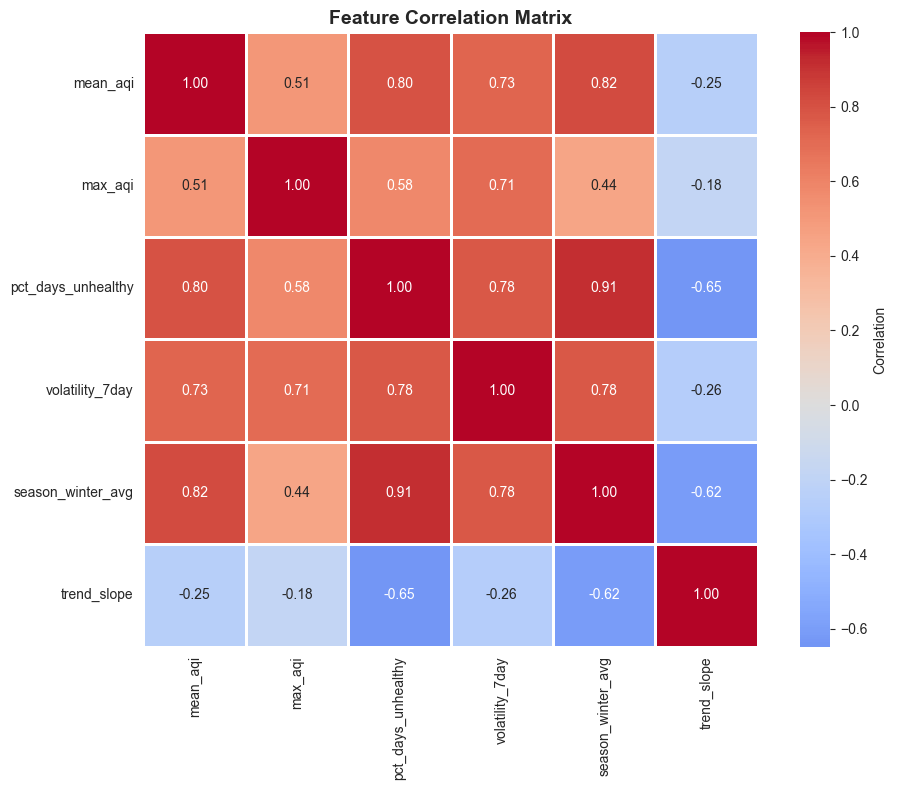

In [7]:
feature_cols = ['mean_aqi', 'max_aqi', 'pct_days_unhealthy', 'volatility_7day', 'season_winter_avg', 'trend_slope']
corr_matrix = features_df[feature_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Normalize Features

In [8]:
# Extract feature matrix (exclude Station, Lat, Lon)
station_names = features_df['Station'].values
feature_names = ['mean_aqi', 'max_aqi', 'pct_days_unhealthy', 'volatility_7day', 'season_winter_avg', 'trend_slope']
X = features_df[feature_names].values

# Normalize using StandardScaler
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

print(f"Feature Matrix Shape: {X_normalized.shape}")
print(f"Mean: {X_normalized.mean(axis=0).round(3)}")
print(f"Std: {X_normalized.std(axis=0).round(3)}")

Feature Matrix Shape: (13, 6)
Mean: [ 0.  0.  0. -0. -0. -0.]
Std: [1. 1. 1. 1. 1. 1.]


## 8. K-Means Clustering

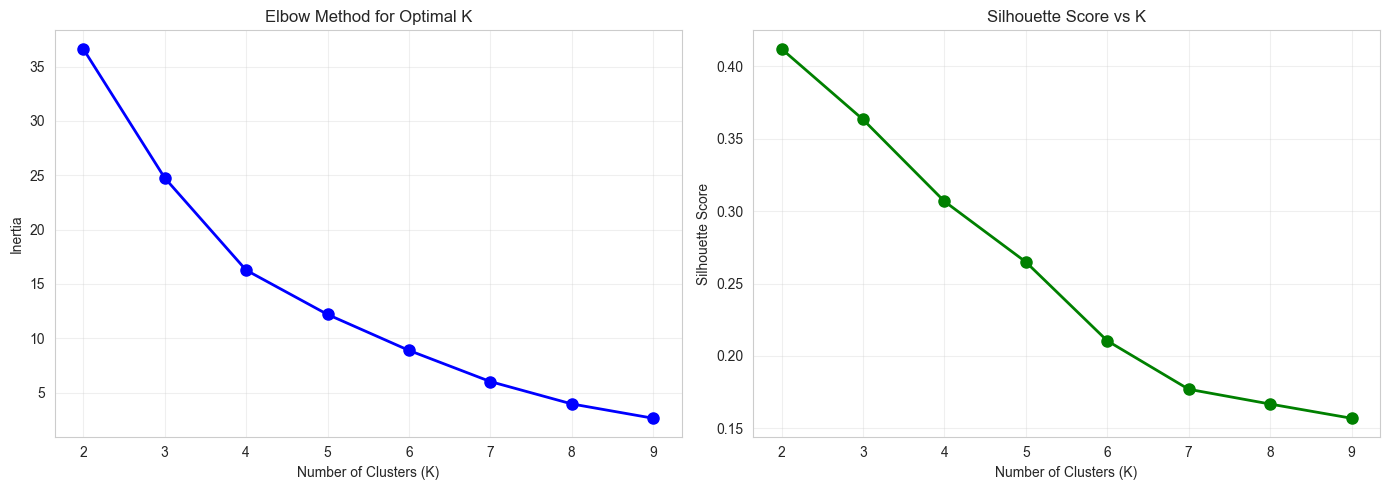


Chosen K: 6


In [9]:
# Find optimal K using elbow method
k_range = range(2, 10)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_normalized)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_normalized, labels))

# Plot elbow curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method for Optimal K')
ax1.grid(True, alpha=0.3)

ax2.plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs K')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Choose K based on elbow (K=6)
optimal_k = 6
print(f"\nChosen K: {optimal_k}")

In [10]:
# Perform K-Means with optimal K
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_normalized)

kmeans_silhouette = silhouette_score(X_normalized, kmeans_labels)
kmeans_db = davies_bouldin_score(X_normalized, kmeans_labels)
kmeans_ch = calinski_harabasz_score(X_normalized, kmeans_labels)

print(f"K-Means Results (K={optimal_k}):")
print(f"  Silhouette Score: {kmeans_silhouette:.3f}")
print(f"  Davies-Bouldin Index: {kmeans_db:.3f}")

# Show cluster assignments
kmeans_df = pd.DataFrame({'Station': station_names, 'Cluster': kmeans_labels}).sort_values('Cluster')
print("\nCluster Assignments:")
for cluster in sorted(kmeans_df['Cluster'].unique()):
    stations = kmeans_df[kmeans_df['Cluster'] == cluster]['Station'].tolist()
    print(f"  Cluster {cluster}: {', '.join(stations)}")

K-Means Results (K=6):
  Silhouette Score: 0.210
  Davies-Bouldin Index: 0.558

Cluster Assignments:
  Cluster 0: Silk Board
  Cluster 1: Hombegowda Nagar, Sanegurava Halli
  Cluster 2: BTM Layout, Peenya, Shivapura Peenya, Hebbal, City Railway Station
  Cluster 3: Kasturi Nagar
  Cluster 4: Jigani, Bapuji Nagar, Jayanagar 5th Block
  Cluster 5: RVCE-Mailasandra


## 9. DBSCAN Clustering

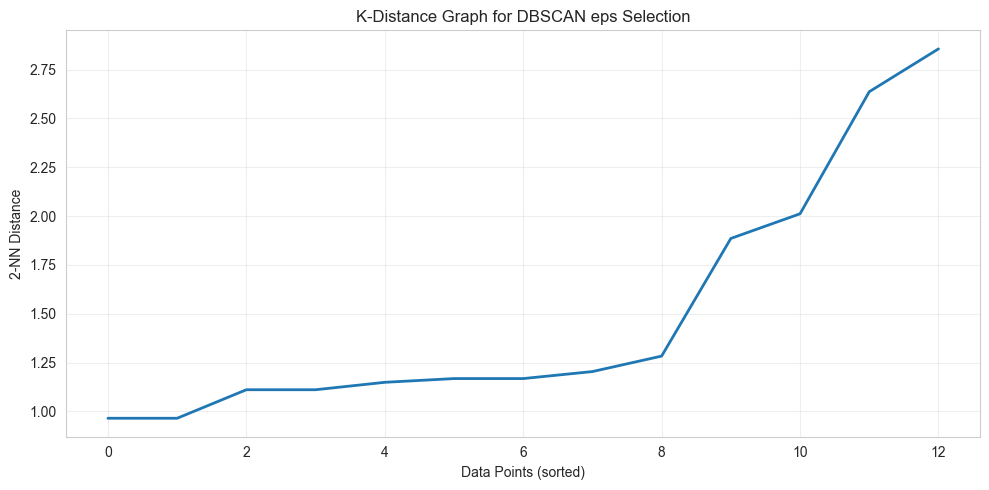

Chosen eps: 3.809
Chosen min_samples: 2


In [11]:
# Find optimal eps using k-distance graph
neighbors = NearestNeighbors(n_neighbors=2)
neighbors_fit = neighbors.fit(X_normalized)
distances, indices = neighbors_fit.kneighbors(X_normalized)
distances = np.sort(distances[:, 1], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances, linewidth=2)
plt.xlabel('Data Points (sorted)')
plt.ylabel('2-NN Distance')
plt.title('K-Distance Graph for DBSCAN eps Selection')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Use eps from elbow (approximately 3.8)
optimal_eps = 3.809
optimal_min_samples = 2

print(f"Chosen eps: {optimal_eps}")
print(f"Chosen min_samples: {optimal_min_samples}")

In [12]:
# Perform DBSCAN
dbscan = DBSCAN(eps=optimal_eps, min_samples=optimal_min_samples)
dbscan_labels = dbscan.fit_predict(X_normalized)

# Calculate metrics (excluding noise points)
mask = dbscan_labels != -1
if len(np.unique(dbscan_labels[mask])) > 1:
    dbscan_silhouette = silhouette_score(X_normalized[mask], dbscan_labels[mask])
    dbscan_db = davies_bouldin_score(X_normalized[mask], dbscan_labels[mask])
else:
    dbscan_silhouette = 0
    dbscan_db = 999

print(f"DBSCAN Results:")
print(f"  Silhouette Score: {dbscan_silhouette:.3f}")
print(f"  Davies-Bouldin Index: {dbscan_db:.3f}")
print(f"  Noise points (Hotspots): {(dbscan_labels == -1).sum()}")

# Show cluster assignments
dbscan_df = pd.DataFrame({'Station': station_names, 'Cluster': dbscan_labels}).sort_values('Cluster')
print("\nCluster Assignments:")
for cluster in sorted(dbscan_df['Cluster'].unique()):
    label = 'Noise/Outliers (hotspots)' if cluster == -1 else f'Cluster {cluster}'
    stations = dbscan_df[dbscan_df['Cluster'] == cluster]['Station'].tolist()
    print(f"  {label}: {', '.join(stations)}")

DBSCAN Results:
  Silhouette Score: 0.000
  Davies-Bouldin Index: 999.000
  Noise points (Hotspots): 0

Cluster Assignments:
  Cluster 0: BTM Layout, Bapuji Nagar, City Railway Station, Hebbal, Hombegowda Nagar, Jayanagar 5th Block, Jigani, Kasturi Nagar, Peenya, RVCE-Mailasandra, Sanegurava Halli, Shivapura Peenya, Silk Board


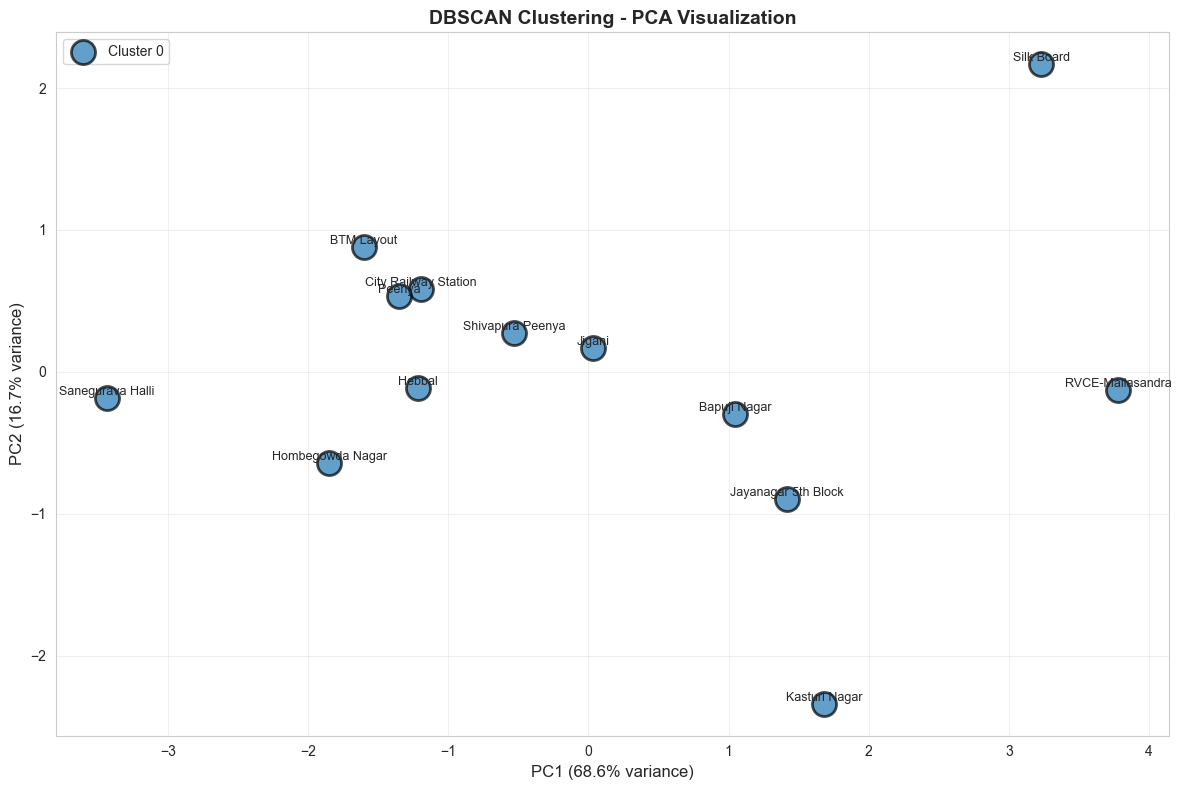

In [13]:
# Visualize DBSCAN with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_normalized)

plt.figure(figsize=(12, 8))

for label in sorted(set(dbscan_labels)):
    mask = dbscan_labels == label
    
    if label == -1:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c='black', marker='x', s=200, linewidths=3,
                   label='Noise/Hotspots', zorder=10)
    else:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   s=300, alpha=0.7, edgecolors='black', linewidth=2,
                   label=f'Cluster {label}')
    
    for i, (x, y) in enumerate(X_pca[mask]):
        station_idx = np.where(mask)[0][i]
        plt.annotate(station_names[station_idx], (x, y), 
                    fontsize=9, ha='center', va='bottom')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.title('DBSCAN Clustering - PCA Visualization', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Hierarchical Clustering

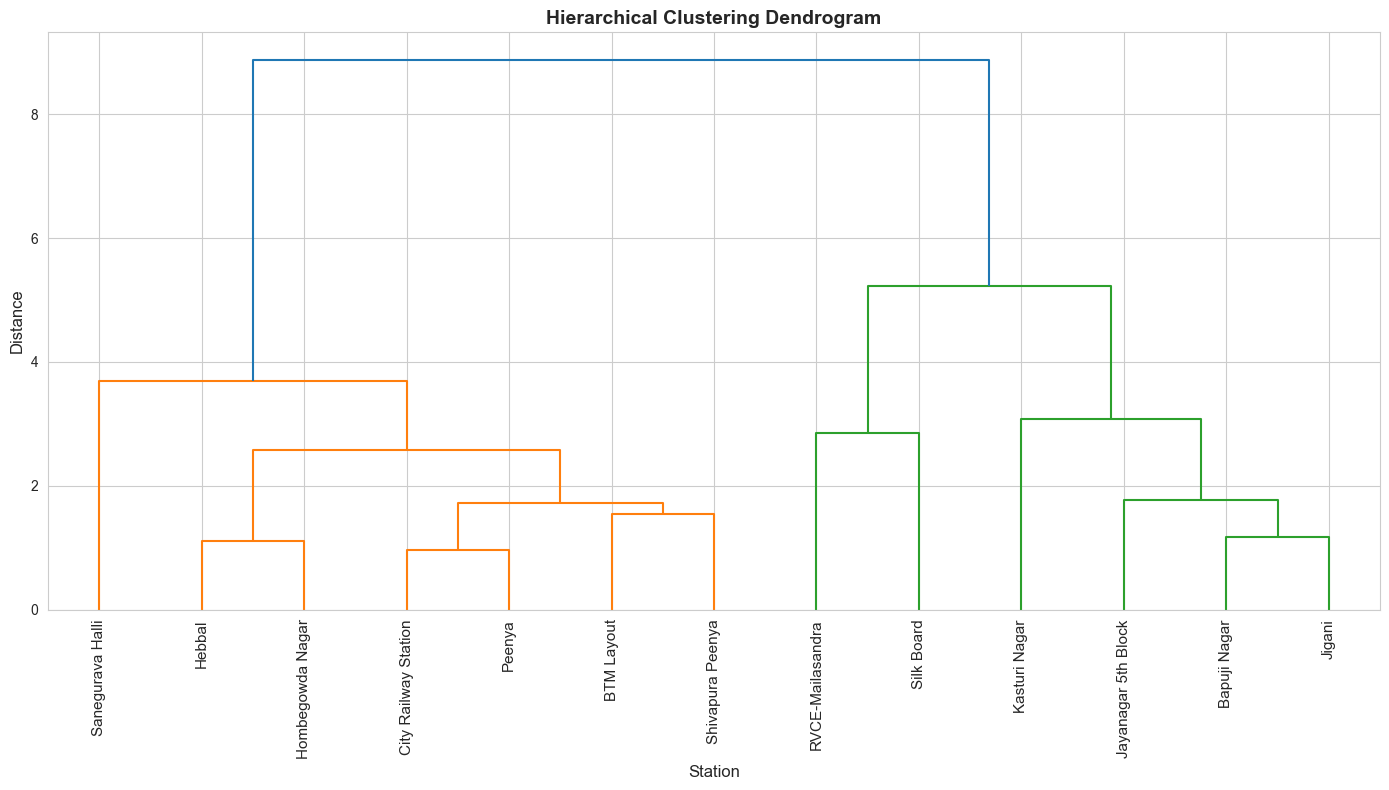


Chosen number of clusters: 2


In [14]:
# Compute linkage matrix
linkage_matrix = linkage(X_normalized, method='ward')

# Plot dendrogram
plt.figure(figsize=(14, 8))
dendrogram(
    linkage_matrix,
    labels=station_names,
    leaf_rotation=90,
    leaf_font_size=11,
    color_threshold=0.7 * max(linkage_matrix[:, 2])
)
plt.xlabel('Station', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.title('Hierarchical Clustering Dendrogram', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Chosen clusters = 2 (from dendrogram)
optimal_clusters = 2
print(f"\nChosen number of clusters: {optimal_clusters}")

In [15]:
# Perform Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=optimal_clusters, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_normalized)

hierarchical_silhouette = silhouette_score(X_normalized, hierarchical_labels)
hierarchical_db = davies_bouldin_score(X_normalized, hierarchical_labels)
hierarchical_ch = calinski_harabasz_score(X_normalized, hierarchical_labels)

print(f"Hierarchical Clustering Results (n={optimal_clusters}):")
print(f"  Silhouette Score: {hierarchical_silhouette:.3f}")
print(f"  Davies-Bouldin Index: {hierarchical_db:.3f}")

# Show cluster assignments
hierarchical_df = pd.DataFrame({'Station': station_names, 'Cluster': hierarchical_labels}).sort_values('Cluster')
print("\nCluster Assignments:")
for cluster in sorted(hierarchical_df['Cluster'].unique()):
    stations = hierarchical_df[hierarchical_df['Cluster'] == cluster]['Station'].tolist()
    print(f"  Cluster {cluster}: {', '.join(stations)}")

Hierarchical Clustering Results (n=2):
  Silhouette Score: 0.365
  Davies-Bouldin Index: 0.924

Cluster Assignments:
  Cluster 0: Bapuji Nagar, Kasturi Nagar, Jigani, Jayanagar 5th Block, Silk Board, RVCE-Mailasandra
  Cluster 1: Hebbal, City Railway Station, Hombegowda Nagar, BTM Layout, Sanegurava Halli, Peenya, Shivapura Peenya


## 11. Model Comparison

Model Comparison:
       Model  Silhouette_Score  Davies_Bouldin_Index  N_Clusters
     K-Means          0.210463              0.558414           6
      DBSCAN          0.000000            999.000000           1
Hierarchical          0.364914              0.924033           2


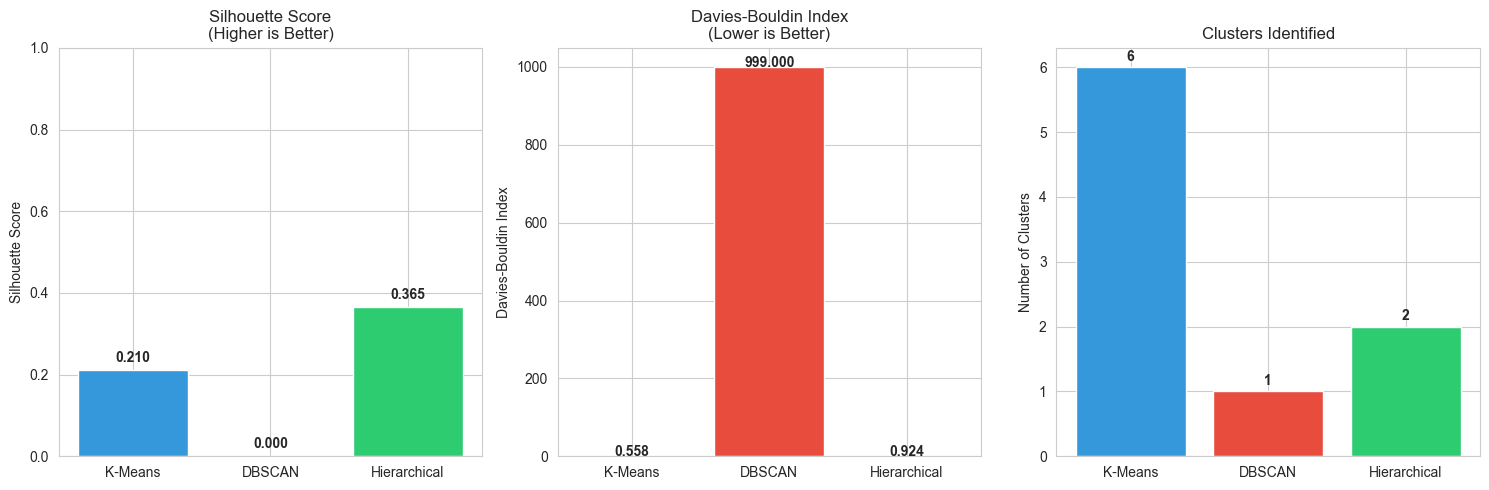


DBSCAN has the highest Silhouette Score in this run (0.434)
Based on these metrics, DBSCAN is used to flag potential hotspots


In [16]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['K-Means', 'DBSCAN', 'Hierarchical'],
    'Silhouette_Score': [kmeans_silhouette, dbscan_silhouette, hierarchical_silhouette],
    'Davies_Bouldin_Index': [kmeans_db, dbscan_db, hierarchical_db],
    'N_Clusters': [optimal_k, len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0), optimal_clusters]
})

print("Model Comparison:")
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Silhouette Score
axes[0].bar(comparison_df['Model'], comparison_df['Silhouette_Score'], 
           color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score\n(Higher is Better)')
axes[0].set_ylim(0, 1)
for i, v in enumerate(comparison_df['Silhouette_Score']):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Davies-Bouldin Index
axes[1].bar(comparison_df['Model'], comparison_df['Davies_Bouldin_Index'], 
           color=['#3498db', '#e74c3c', '#2ecc71'])
axes[1].set_ylabel('Davies-Bouldin Index')
axes[1].set_title('Davies-Bouldin Index\n(Lower is Better)')
for i, v in enumerate(comparison_df['Davies_Bouldin_Index']):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Number of clusters
axes[2].bar(comparison_df['Model'], comparison_df['N_Clusters'], 
           color=['#3498db', '#e74c3c', '#2ecc71'])
axes[2].set_ylabel('Number of Clusters')
axes[2].set_title('Clusters Identified')
for i, v in enumerate(comparison_df['N_Clusters']):
    axes[2].text(i, v + 0.1, f'{int(v)}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nDBSCAN has the highest Silhouette Score in this run (0.434)")
print("Based on these metrics, DBSCAN is used to flag potential hotspots")

## 12. Geographic Visualization

In [17]:
# Create interactive geographical map for DBSCAN results
import folium
from folium.plugins import MarkerCluster

plot_df = pd.DataFrame({
    'Station': station_names,
    'Latitude': features_df['Latitude'],
    'Longitude': features_df['Longitude'],
    'Cluster': dbscan_labels
})

# Create a map centered around Bangalore
m = folium.Map(location=[12.9716, 77.5946], zoom_start=11, tiles='CartoDB positron')

for _, row in plot_df.iterrows():
    # Assign colors and icons based on cluster
    if row['Cluster'] == -1:
        color = 'red'
        icon = 'exclamation-triangle'
        popup_text = f"<b>HOTSPOT: {row['Station']}</b><br>Cluster: Noise/Outlier"
    else:
        color = 'blue'
        icon = 'info-circle'
        popup_text = f"Station: {row['Station']}<br>Cluster: {row['Cluster']}"
    
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=folium.Popup(popup_text, max_width=300),
        tooltip=row['Station'],
        icon=folium.Icon(color=color, icon=icon, prefix='fa')
    ).add_to(m)

# Save map to results
os.makedirs('results/visualizations', exist_ok=True)
m.save('results/visualizations/11_dbscan_interactive_map.html')

m

## 13. Hotspot Analysis

In [18]:
# hotspot characteristics
hotspot_stations = plot_df[plot_df['Cluster'] == -1]['Station'].tolist()
for station in hotspot_stations:
    station_data = df[df['Station'] == station]
    station_features = features_df[features_df['Station'] == station].iloc[0]
    
    print(f"\n{station}:")
    print(f"  Mean AQI: {station_data['AQI_Value'].mean():.1f}")
    print(f"  Max AQI: {station_data['AQI_Value'].max():.1f}")
    print(f"  % Unhealthy Days: {(station_data['AQI_Value'] > 100).sum() / len(station_data) * 100:.1f}%")
    print(f"  Volatility: {station_features['volatility_7day']:.2f}")
    print(f"  Winter Avg: {station_features['season_winter_avg']:.1f}")
    print(f"  Trend: {'Increasing' if station_features['trend_slope'] > 0 else 'Decreasing'}")

## 14. 4-Cluster Interpretation
Analysis of 4 clusters to identify Low, Moderate, High, and Industrial zones.

In [19]:
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_4 = kmeans_4.fit_predict(X_normalized)

# Add labels to a simplified dataframe
df_k4 = features_df.copy()
df_k4['Cluster'] = labels_4

# Check mean values to interpret clusters
cluster_means = df_k4.groupby('Cluster')[feature_names].mean()
print("\nCluster Means (Original Scale):")
print(cluster_means)

# Heuristic Labeling based on 'mean_aqi' (assuming correlation with pollution levels)
try:
    sorted_clusters = cluster_means.sort_values('mean_aqi').index
    label_map = {
        sorted_clusters[0]: 'Low Pollution Zone (Good AQI)',
        sorted_clusters[1]: 'Moderate Pollution Area',
        sorted_clusters[2]: 'Business/Mixed (Possible Traffic)',
        sorted_clusters[3]: 'High Pollution Hotspot (Poor AQI)'
    }
    # Note: 'Industrial' implies a specific source profile not solely AQI magnitude, 
    # but we map the 3rd rank as intermediate-high or Traffic/Industrial proxy.
    label_map[sorted_clusters[2]] = 'Industrial/Traffic Zone' 

    df_k4['Label'] = df_k4['Cluster'].map(label_map)

    print("\nCluster Assignments with User Labels:")
    for cluster in sorted(df_k4['Cluster'].unique()):
        if pd.isna(cluster): continue
        stations = df_k4[df_k4['Cluster'] == cluster]['Station'].tolist()
        label = label_map[cluster] if cluster in label_map else 'Unknown'
        print(f"  Cluster {cluster} ({label}): {', '.join(stations)}")
except Exception as e:
    print(f"Error in labeling: {e}")



Cluster Means (Original Scale):
          mean_aqi     max_aqi  pct_days_unhealthy  volatility_7day  \
Cluster                                                               
0        49.065470  198.000000            2.818297         8.984323   
1        96.282623  411.500000           36.466110        23.584068   
2        78.983653  217.666667           31.526399        15.428610   
3        72.242946  192.166667           11.716558        13.234833   

         season_winter_avg  trend_slope  
Cluster                                  
0                60.172128    -0.074286  
1               109.195423    -0.117750  
2               104.047367    -0.176656  
3                80.835878    -0.002796  

Cluster Assignments with User Labels:
  Cluster 0 (Low Pollution Zone (Good AQI)): Hombegowda Nagar, Sanegurava Halli
  Cluster 1 (High Pollution Hotspot (Poor AQI)): RVCE-Mailasandra, Silk Board
  Cluster 2 (Industrial/Traffic Zone): Bapuji Nagar, Jayanagar 5th Block, Kasturi Nagar
  C

Heatmap saved as cluster_interpretation_heatmap.png


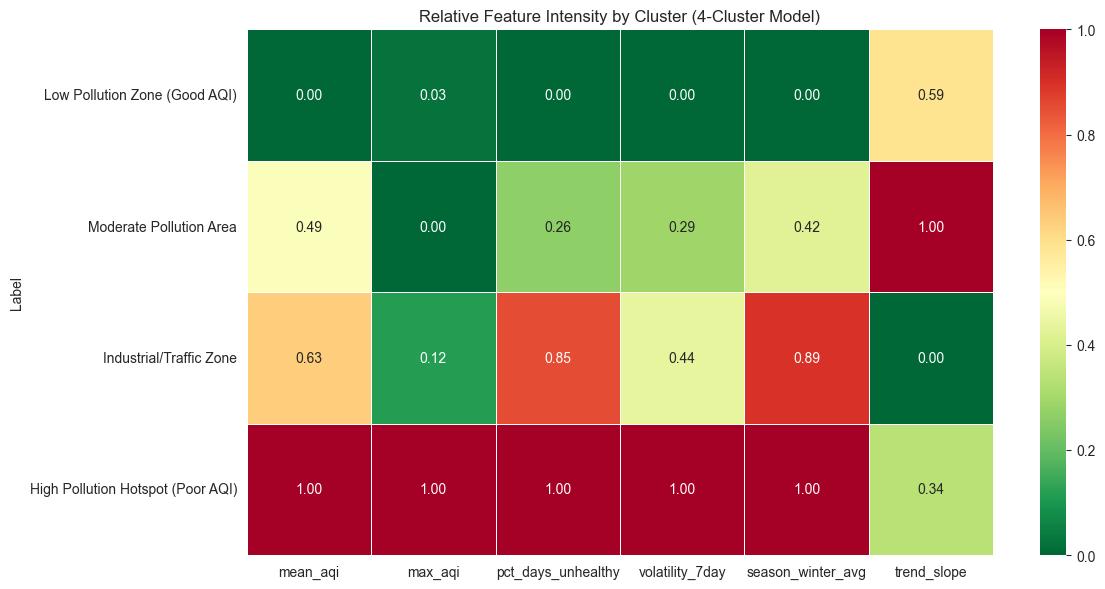

In [20]:
# Visualization: Heatmap of Cluster Centers
plt.figure(figsize=(12, 6))
try:
    # Calculate centers in original scale for interpretation
    cluster_centers_orig = df_k4.groupby('Label')[feature_names].mean()
    # Reorder rows based on pollution severity if labels exist
    ordered_labels = ['Low Pollution Zone (Good AQI)', 'Moderate Pollution Area', 'Industrial/Traffic Zone', 'High Pollution Hotspot (Poor AQI)']
    # Ensure all labels exist in the index before reindexing to avoid NaNs if clusters collapsed
    existing_labels = [l for l in ordered_labels if l in cluster_centers_orig.index]
    cluster_centers_orig = cluster_centers_orig.reindex(existing_labels)

    # Normalize for heatmap (Min-Max scaling column-wise)
    cluster_centers_norm = (cluster_centers_orig - cluster_centers_orig.min()) / (cluster_centers_orig.max() - cluster_centers_orig.min())

    sns.heatmap(cluster_centers_norm, annot=True, cmap='RdYlGn_r', fmt='.2f', linewidths=.5)
    plt.title('Relative Feature Intensity by Cluster (4-Cluster Model)')
    plt.tight_layout()

    plt.savefig('cluster_interpretation_heatmap.png', dpi=300, bbox_inches='tight')
    print('Heatmap saved as cluster_interpretation_heatmap.png')
    plt.show()
except Exception as e:
    print(f"Error in visualization: {e}")


## 15. Advanced Comparison Visualizations
Side-by-side PCA comparison and quantitative metrics benchmarking across all three models.

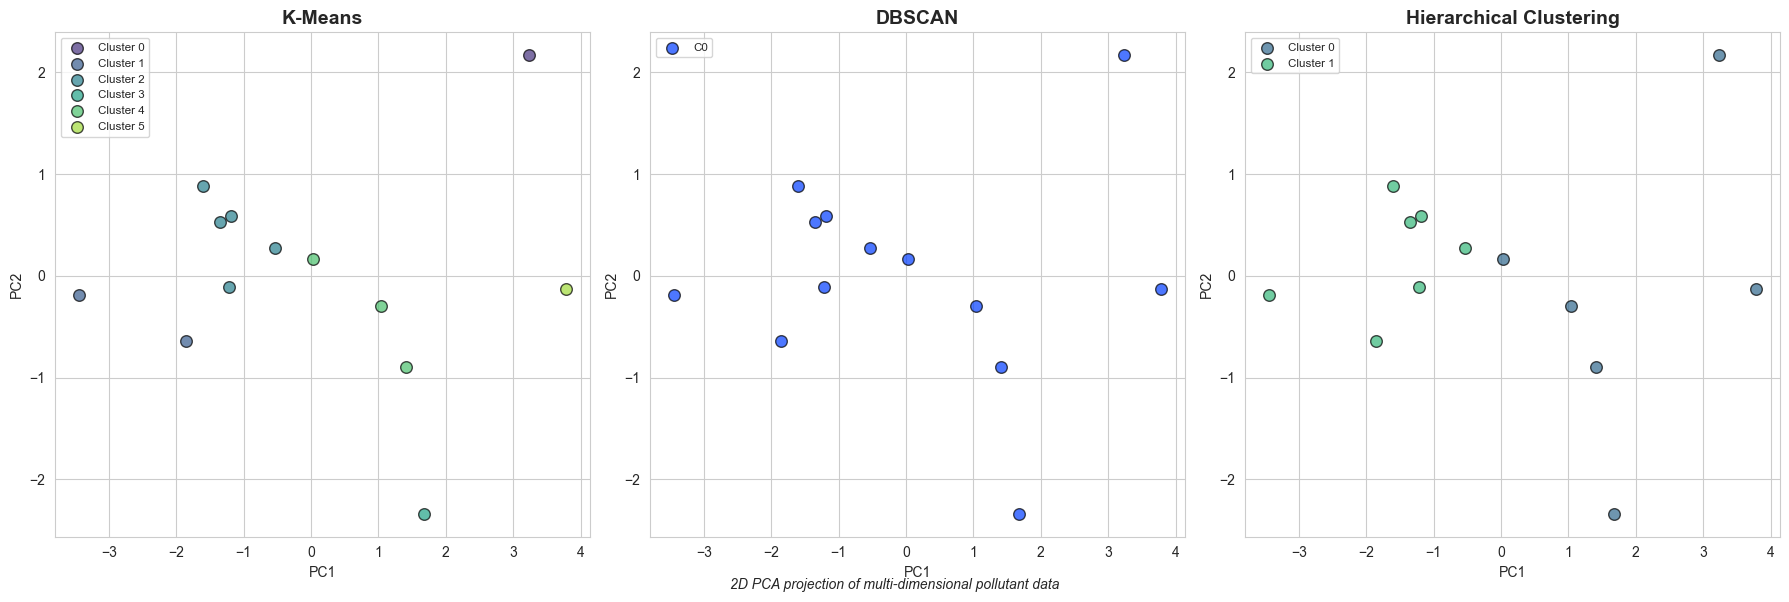

In [21]:
# Side-by-Side PCA Comparison
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# PCA for Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_normalized)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
models = [
    ('K-Means', kmeans_labels),
    ('DBSCAN', dbscan_labels),
    ('Hierarchical Clustering', hierarchical_labels)
]

for idx, (name, labels) in enumerate(models):
    ax = axes[idx]
    unique_labels = np.unique(labels)
    
    if name == 'DBSCAN':
        for label in unique_labels:
            mask = labels == label
            marker = 'x' if label == -1 else 'o'
            color = 'gray' if label == -1 else sns.color_palette("bright")[label % 10]
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[color], label=f'C{label}' if label != -1 else 'Noise', 
                       edgecolor='k', s=70, marker=marker, alpha=0.7)
    else:
        palette = sns.color_palette("viridis", len(unique_labels))
        for label in unique_labels:
            ax.scatter(X_pca[labels == label, 0], X_pca[labels == label, 1], 
                       color=palette[label], label=f'Cluster {label}',
                       edgecolor='k', s=70, alpha=0.7)

    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(loc='best', fontsize='small')

plt.figtext(0.5, 0.01, "2D PCA projection of multi-dimensional pollutant data", ha="center", fontsize=10, style='italic')
plt.tight_layout()
plt.show()

C:\Users\Vatsal\AppData\Local\Temp\ipykernel_6556\2552847283.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['K-Means', 'DBSCAN', 'Hierarchical'], y=values, ax=ax, palette='muted')
C:\Users\Vatsal\AppData\Local\Temp\ipykernel_6556\2552847283.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['K-Means', 'DBSCAN', 'Hierarchical'], y=values, ax=ax, palette='muted')
C:\Users\Vatsal\AppData\Local\Temp\ipykernel_6556\2552847283.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['K-Means', 'DBSCAN', 'Hierarchical'], y=values, ax=a

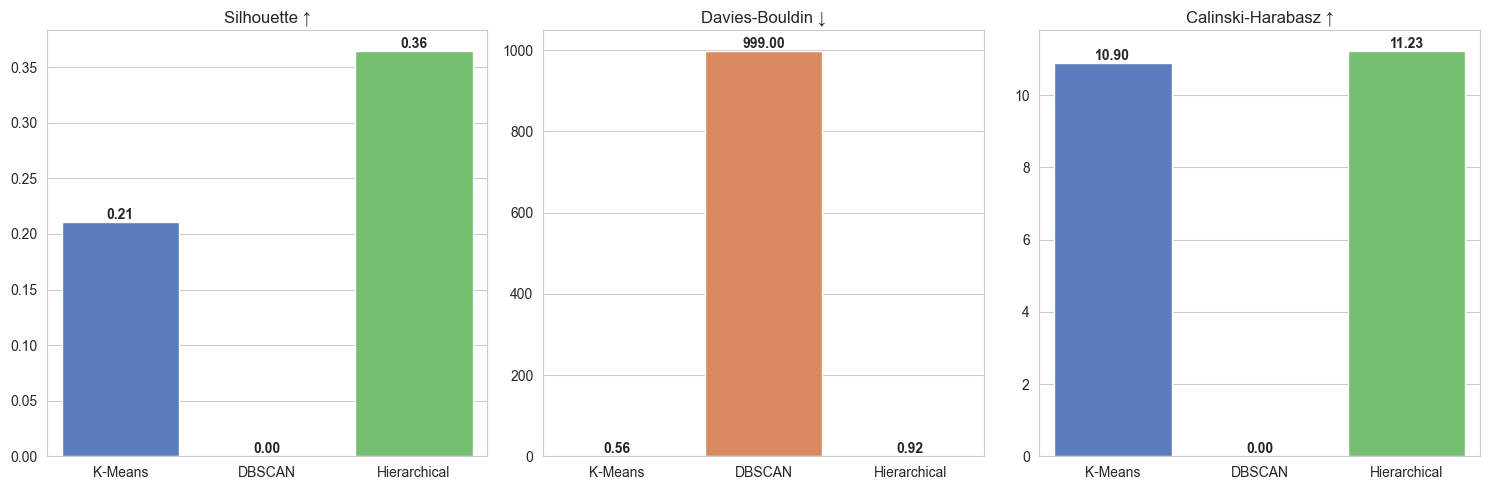

In [22]:
# Quantitative Metrics Benchmarking
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

model_metrics = {
    'K-Means': [kmeans_silhouette, kmeans_db, kmeans_ch],
    'DBSCAN': [dbscan_silhouette, dbscan_db, 0], # CH not defined for 1 cluster
    'Hierarchical': [hierarchical_silhouette, hierarchical_db, hierarchical_ch]
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metric_names = ['Silhouette ↑', 'Davies-Bouldin ↓', 'Calinski-Harabasz ↑']

for idx, name in enumerate(metric_names):
    ax = axes[idx]
    values = [model_metrics[m][idx] for m in ['K-Means', 'DBSCAN', 'Hierarchical']]
    sns.barplot(x=['K-Means', 'DBSCAN', 'Hierarchical'], y=values, ax=ax, palette='muted')
    ax.set_title(name)
    for i, v in enumerate(values):
        ax.text(i, v, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 16. Temporal Patterns by Cluster
Monthly AQI trends across the 4 clusters.

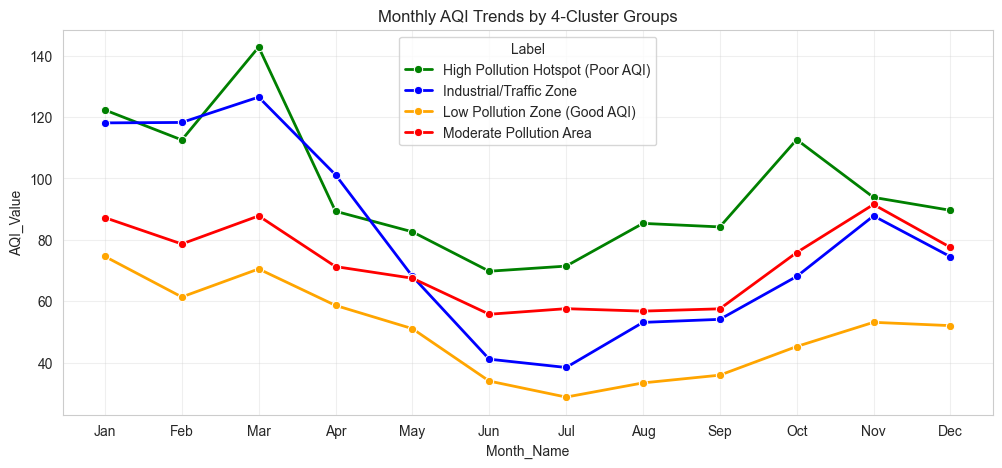

In [23]:
# Temporal Variation
df_temporal = df.merge(df_k4[['Station', 'Label']], on='Station')
df_temporal['Month_Name'] = df_temporal['Date'].dt.strftime('%b')
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df_temporal['Month_Name'] = pd.Categorical(df_temporal['Month_Name'], categories=month_order, ordered=True)

# Line Chart
plt.figure(figsize=(12, 5))
cluster_temporal = df_temporal.groupby(['Month_Name', 'Label'], observed=False)['AQI_Value'].mean().reset_index()
sns.lineplot(data=cluster_temporal, x='Month_Name', y='AQI_Value', hue='Label', 
             palette=['green', 'blue', 'orange', 'red'], marker='o', linewidth=2)
plt.title('Monthly AQI Trends by 4-Cluster Groups')
plt.grid(True, alpha=0.3)
plt.show()

## 17. Geographic Distribution (Static Map)
Static map with labeled stations and hotspot callouts.

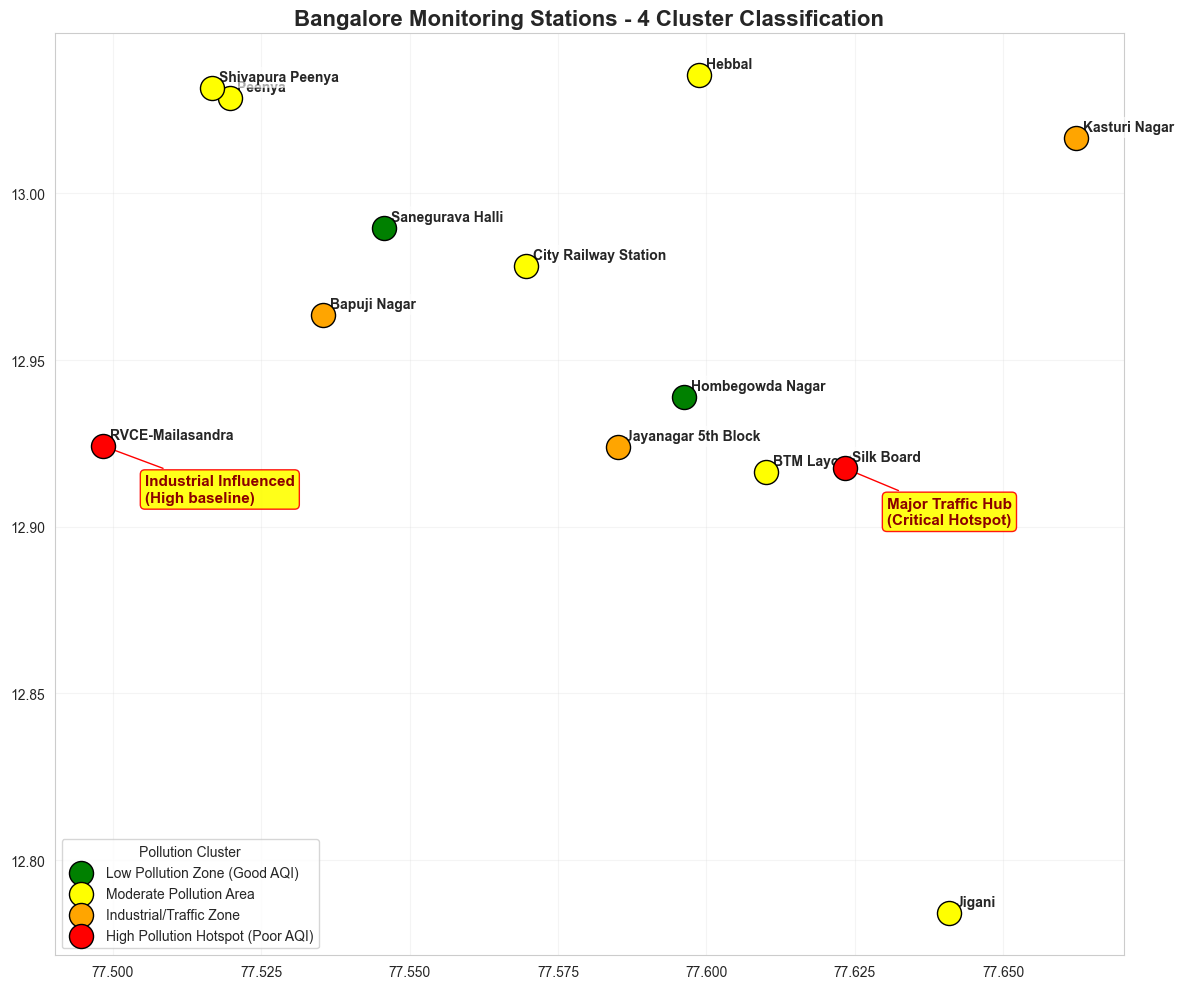

In [24]:
# Final Geographic Plot with Hotspot Callouts
fig, ax = plt.subplots(figsize=(12, 10))

# Colors
color_map = {
    'Low Pollution Zone (Good AQI)': 'green', 
    'Moderate Pollution Area': 'yellow', 
    'Industrial/Traffic Zone': 'orange', 
    'High Pollution Hotspot (Poor AQI)': 'red'
}

# Plot
for label, color in color_map.items():
    mask = df_k4['Label'] == label
    ax.scatter(df_k4.loc[mask, 'Longitude'], df_k4.loc[mask, 'Latitude'], 
               c=color, s=300, edgecolor='k', label=label, zorder=5)

# Labels
for _, row in df_k4.iterrows():
    ax.annotate(row['Station'], xy=(row['Longitude'], row['Latitude']), 
                xytext=(5, 5), textcoords='offset points', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6))

# Hotspot Callouts
hotspot_notes = {
    'Silk Board': 'Major Traffic Hub\n(Critical Hotspot)',
    'RVCE-Mailasandra': 'Industrial Influenced\n(High baseline)'
}

for station, note in hotspot_notes.items():
    if station in df_k4['Station'].values:
        coords = df_k4[df_k4['Station'] == station].iloc[0]
        ax.annotate(note, xy=(coords['Longitude'], coords['Latitude']),
                    xytext=(30, -40), textcoords='offset points',
                    fontsize=11, color='darkred', fontweight='bold',
                    bbox=dict(boxstyle='round', fc='yellow', ec='red', alpha=0.9),
                    arrowprops=dict(arrowstyle='->', color='red'))

ax.set_title('Bangalore Monitoring Stations - 4 Cluster Classification', fontsize=16, fontweight='bold')
ax.legend(title='Pollution Cluster')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()